# Car Price Prediction with Machine Learning
**CodeAlpha Data Science Internship, Task 3**

The goal here is to train a regression model that can predict a used car's selling price using features like the brand, how old the car is, its original showroom price, kilometers driven, fuel type, and transmission type.

## 1. Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 6)

## 2. Loading the dataset

In [2]:
# dataset from the link CodeAlpha shared for this task
df = pd.read_csv("data/car_data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print(df.shape)
df.info()
print("\nMissing values:\n", df.isnull().sum())

(301, 9)
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB

Missing values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


## 3. Engineering a couple of features

In [4]:
# the raw Year isn't as useful to a model as how old the car actually is
current_year = 2024
df["Car_Age"] = current_year - df["Year"]
df.drop(columns=["Year"], inplace=True)

# heads up: Selling_Price and Present_Price are both in lakhs (Indian currency units)
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


## 4. Exploring the data

In [5]:
df.describe()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,4.661296,7.628472,36947.205980,0.043189,10.372093
std,5.082812,8.642584,38886.883882,0.247915,2.891554
min,0.100000,0.320000,500.000000,0.000000,6.000000
25%,0.900000,1.200000,15000.000000,0.000000,8.000000
50%,3.600000,6.400000,32000.000000,0.000000,10.000000
75%,6.000000,9.900000,48767.000000,0.000000,12.000000
max,35.000000,92.600000,500000.000000,3.000000,21.000000


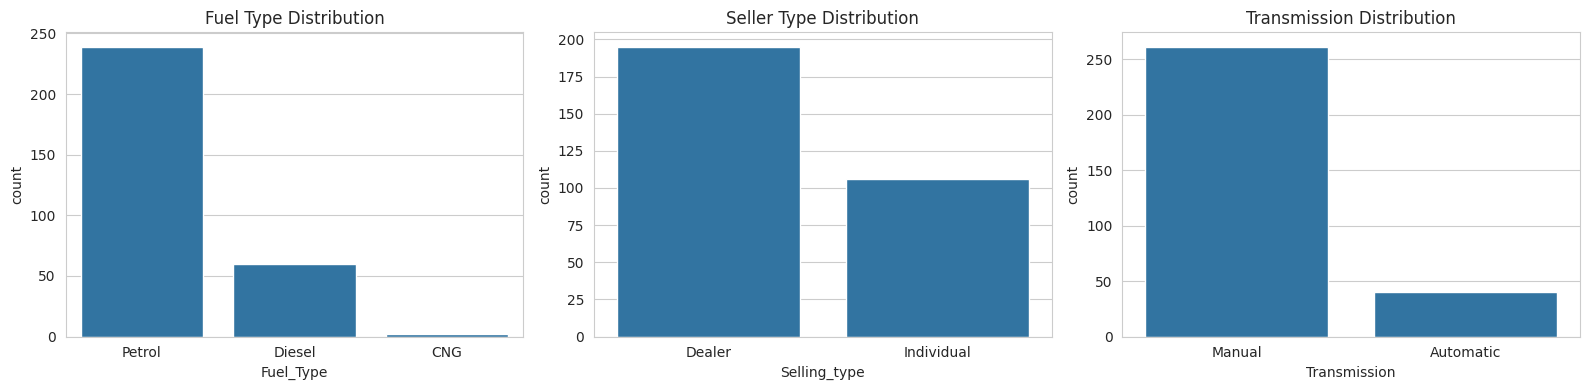

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x="Fuel_Type", ax=axes[0])
axes[0].set_title("Fuel Type Distribution")
sns.countplot(data=df, x="Selling_type", ax=axes[1])
axes[1].set_title("Seller Type Distribution")
sns.countplot(data=df, x="Transmission", ax=axes[2])
axes[2].set_title("Transmission Distribution")
plt.tight_layout()
plt.show()

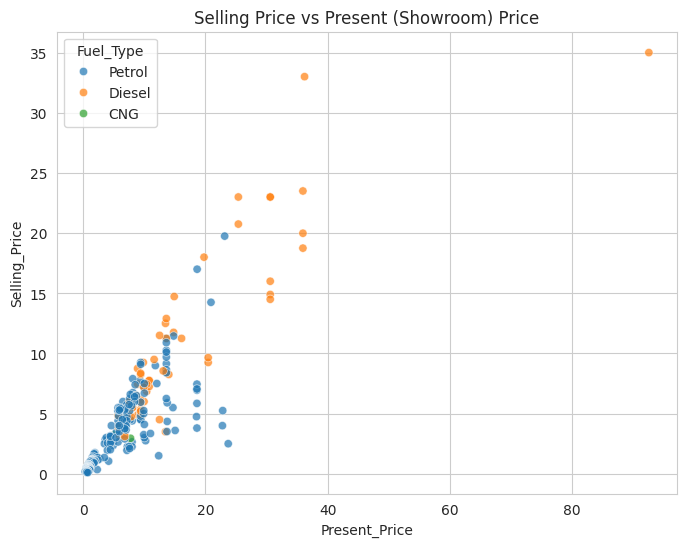

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price", hue="Fuel_Type", alpha=0.7)
plt.title("Selling Price vs Present (Showroom) Price")
plt.show()

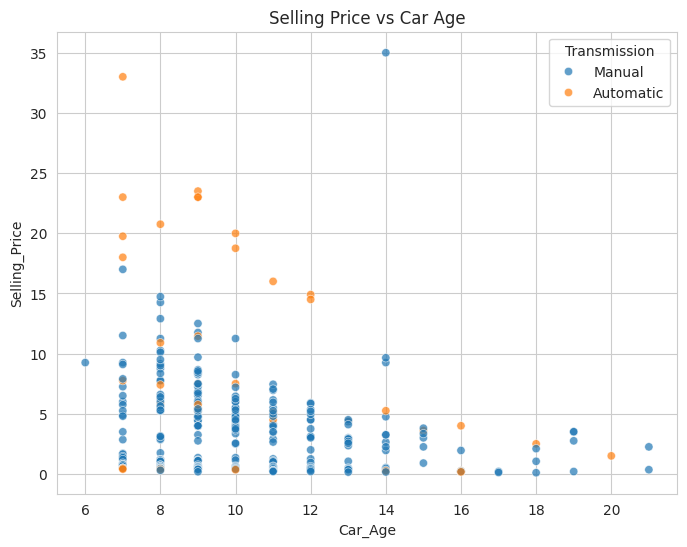

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Car_Age", y="Selling_Price", hue="Transmission", alpha=0.7)
plt.title("Selling Price vs Car Age")
plt.show()

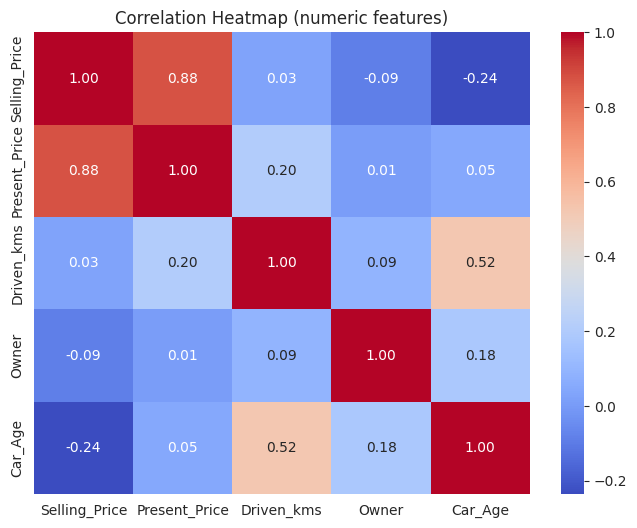

In [9]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (numeric features)")
plt.show()

**What I noticed:** `Present_Price` (the showroom price) is strongly correlated with `Selling_Price`, which makes sense, a car's resale value is mostly anchored to what it originally cost. Older cars (higher `Car_Age`) tend to sell for less, and both transmission type and fuel type shift the price somewhat too.

## 5. Preprocessing the data

In [10]:
# dropping Car_Name since it has too many unique values to one-hot encode usefully
df_model = df.drop(columns=["Car_Name"])

categorical_cols = ["Fuel_Type", "Selling_type", "Transmission"]
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

X = df_model.drop(columns=["Selling_Price"])
y = df_model["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
X.head()

Train shape: (240, 8)  Test shape: (61, 8)


,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,5.59,27000,0,10,False,True,False,True
1,9.54,43000,0,11,True,False,False,True
2,9.85,6900,0,7,False,True,False,True
3,4.15,5200,0,13,False,True,False,True
4,6.87,42450,0,10,True,False,False,True


## 6. Training and comparing a few regression models

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=6),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse})
    print(f"{name:20s} R2: {r2:.4f}  MAE: {mae:.3f}  RMSE: {rmse:.3f}")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

Linear Regression    R2: 0.8489  MAE: 1.216  RMSE: 1.866
Lasso Regression     R2: 0.8444  MAE: 1.227  RMSE: 1.893
Decision Tree        R2: 0.9444  MAE: 0.714  RMSE: 1.132


Random Forest        R2: 0.9622  MAE: 0.615  RMSE: 0.933


,Model,R2,MAE,RMSE
3,Random Forest,0.962188,0.615303,0.933281
2,Decision Tree,0.944403,0.714173,1.131687
0,Linear Regression,0.848871,1.216374,1.865838
1,Lasso Regression,0.844441,1.226744,1.892985


In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="R2", y="Model", hue="Model",
            palette="viridis", legend=False)
plt.title("Model Comparison: R2 Score (higher is better)")
plt.xlim(0, 1)
plt.show()

## 7. Evaluating the best model

In [ ]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
print("Best model:", best_name)

preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds, alpha=0.6, color="teal")
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, "r--", label="Perfect Prediction")
plt.xlabel("Actual Selling Price (Lakhs)")
plt.ylabel("Predicted Selling Price (Lakhs)")
plt.title(f"Actual vs Predicted, {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Feature importance (Random Forest)

In [ ]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="mako", legend=False)
plt.title("Feature Importance from the Random Forest Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
importances

## 9. Conclusion

The showroom price (`Present_Price`) turned out to be by far the strongest predictor of a car's selling price, followed by car age and kilometers driven, which lines up with intuition. The tree-based model (Random Forest) outperformed the simpler linear models here, probably because price depreciation isn't a straight line with age or mileage, it curves.

The best model reached a solid R2 score, meaning it explains most of the variance in selling price, with reasonably low error in both MAE and RMSE (measured in lakhs). In practice, a model like this could power something like an instant "estimated resale value" feature for a used car marketplace or a dealership.